**1. Dataset**

The IMDb Movie Reviews dataset is used for binary sentiment classification. Each review is labeled as either positive (`1`) or negative (`0`).

The dataset contains three splits:

- **Training set:** 25,000 labeled reviews
- **Test set:** 25,000 labeled reviews
- **Unsupervised set:** 50,000 unlabeled reviews

For the custom LSTM, the labeled training set will be divided into training and validation subsets. The test set will remain completely unseen until the final evaluation.

The unsupervised reviews are not used for training the custom LSTM. They will be relevant later when implementing the pretrained language-model approach.

In [1]:
from datasets import load_dataset
def load_data():
    dataset = load_dataset("stanfordnlp/imdb")
    return dataset

In [2]:
# Step 1 : Load the dataset
dataset = load_data()
dataset

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

**1.2 Train-Validation-Test Split**

The original IMDb training set contains 25,000 labeled reviews. To evaluate the model during training without using the final test set, 10% of the training data is reserved for validation.

The resulting datasets are:

- **Training:** 22,500 reviews
- **Validation:** 2,500 reviews
- **Test:** 25,000 reviews

The original IMDb test set is kept completely untouched and is used only for final model evaluation.

A fixed random seed (`42`) is used to ensure that the same train-validation split is produced across different runs, improving reproducibility.

In [3]:
def split_data(dataset):
    train_valid = dataset['train'].train_test_split(test_size=0.1 , seed=42)
    
    train_dataset = train_valid['train']
    valid_dataset = train_valid['test']
    test_dataset  = dataset['test']
    
    return train_dataset, valid_dataset, test_dataset

In [4]:
# Step 2 : Split the dataset into training, validation, and test sets
train_dataset, valid_dataset, test_dataset = split_data(dataset)
print(f"Training samples:   {len(train_dataset):,}")
print(f"Validation samples: {len(valid_dataset):,}")
print(f"Test samples:       {len(test_dataset):,}")

Training samples:   22,500
Validation samples: 2,500
Test samples:       25,000


**3. Text Preprocessing and Tokenization**

The IMDb reviews contain natural language text with varying capitalization and punctuation. Before converting the reviews into numerical sequences, the text is normalized and tokenized.

The preprocessing steps are:

1. Convert all text to lowercase.
2. Remove unnecessary characters while preserving apostrophes in contractions.
3. Normalize consecutive whitespace characters.
4. Split each review into individual word tokens.

For example:

`"I didn't like this movie!!!"`

becomes:

`["i", "didn't", "like", "this", "movie"]`

The resulting tokens will later be used to construct a vocabulary and convert each review into a sequence of integer token IDs.

The vocabulary will be constructed using the training dataset only to prevent information leakage from the validation and test sets.

In [5]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s']", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(example):
    cleaned = clean_text(example["text"])
    return {"tokens": cleaned.split()}

def apply_tokenization(train_ds, valid_ds, test_ds):
    train_ds = train_ds.map(tokenize)
    valid_ds = valid_ds.map(tokenize)
    test_ds = test_ds.map(tokenize)

    return train_ds, valid_ds, test_ds

In [6]:
# Tokenize the datasets
train_ds, valid_ds, test_ds = apply_tokenization(train_dataset, valid_dataset, test_dataset)
print(train_ds.column_names)
print(train_ds[0]["tokens"][:20])

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

['text', 'label', 'tokens']
['with', 'these', 'people', 'faking', 'so', 'many', 'shots', 'using', 'old', 'footage', 'and', 'gassing', 'animals', 'to', 'get', 'them', 'out', 'not', 'to', 'mention']


**4. Vocabulary Construction**

A vocabulary is constructed from the tokenized training dataset by counting the frequency of each word.

Only the training dataset is used to build the vocabulary. This prevents information from the validation and test datasets from influencing the vocabulary.

The vocabulary is limited to the 20,000 most frequent words to control the size of the embedding layer and reduce computational requirements.

Two special tokens are included:

- `<pad>` with index `0` for padding shorter sequences.
- `<unk>` with index `1` for words that are not present in the vocabulary.

The remaining words are assigned integer IDs based on their frequency, starting from index `2`.

In [7]:
from collections import Counter

def build_vocab(train_ds, max_vocab=20000):
    counter = Counter()
    
    for tokens in train_ds["tokens"]:
        counter.update(tokens)
    
    vocab = {"<pad>": 0, "<unk>": 1}
    
    for i, (word, _) in enumerate(counter.most_common(max_vocab - 2), start=2):
        vocab[word] = i
    
    return vocab

In [8]:
# Vocab 
vocab = build_vocab(train_ds)
print(f"Vocabulary size: {len(vocab):,}")
print(list(vocab.items())[:10])

Vocabulary size: 20,000
[('<pad>', 0), ('<unk>', 1), ('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('in', 8), ('it', 9)]


In [9]:
print(vocab["<pad>"])
print(vocab["<unk>"])

0
1


**5. Convert Tokens to Integer IDs**

Neural networks cannot process text tokens directly, so each token is converted into an integer ID using the vocabulary created from the training data.

Words that are not present in the vocabulary are mapped to the `<unk>` token.

Each review is then converted to a fixed-length sequence of 200 token IDs:

- Reviews longer than 200 tokens are truncated.
- Reviews shorter than 200 tokens are padded with `<pad>` tokens.
- `<pad>` has index `0`.
- `<unk>` has index `1`.

Using a fixed sequence length allows the reviews to be efficiently processed in batches by the LSTM.

In [10]:
def encode(example, vocab, max_len=200):
    tokens = example["tokens"]

    ids = [
        vocab.get(token, vocab["<unk>"])
        for token in tokens
    ]

    ids = ids[:max_len]

    padding_length = max_len - len(ids)
    ids += [vocab["<pad>"]] * padding_length

    return {
        "input_ids": ids,
        "label": example["label"]
    }


def apply_encoding(dataset, vocab):
    return dataset.map(
        lambda x: encode(x, vocab)
    )

In [11]:
# Encode the datasets
train_ds = apply_encoding(train_ds, vocab)
valid_ds = apply_encoding(valid_ds, vocab)
test_ds  = apply_encoding(test_ds, vocab)

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [12]:
print(train_ds.column_names)
print(train_ds[0]["input_ids"][:20])
print(len(train_ds[0]["input_ids"]))
print(train_ds[0]["label"])

['text', 'label', 'tokens', 'input_ids']
[17, 130, 83, 12109, 37, 106, 653, 740, 167, 900, 3, 1, 1355, 6, 76, 97, 46, 22, 6, 726]
200
0


**6. Convert Dataset Format to PyTorch**

The encoded Hugging Face datasets are configured to return the model inputs and labels as PyTorch tensors.

Only the following columns are selected for model training:

- `input_ids` — numerical representation of the review
- `label` — binary sentiment label

This allows the datasets to be directly used with PyTorch `DataLoader` objects in the training pipeline.

In [13]:
def set_torch_format(dataset):
    dataset.set_format(
        type="torch",
        columns=["input_ids", "label"]
    )
    return dataset

In [14]:
train_ds = set_torch_format(train_ds)
valid_ds = set_torch_format(valid_ds)
test_ds = set_torch_format(test_ds)

**7. Create PyTorch DataLoaders**

PyTorch `DataLoader` objects are used to load the encoded reviews in mini-batches during model training and evaluation.

A batch size of 16 is used initially.

The training data is shuffled at the beginning of each epoch to reduce the possibility of the model learning from the ordering of the training samples.

The validation and test datasets are not shuffled because they are used only for consistent model evaluation.

In [15]:
from torch.utils.data import DataLoader

def get_dataloader(dataset, batch_size=16, shuffle=False):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle
    )

In [16]:
# Loaders 

train_loader = get_dataloader(
    train_ds,
    shuffle=True
)

valid_loader = get_dataloader(
    valid_ds,
    shuffle=False
)

test_loader = get_dataloader(
    test_ds,
    shuffle=False
)

**8. Custom LSTM Model**

A custom LSTM architecture is implemented from scratch using PyTorch rather than relying on the built-in `nn.LSTM` layer.

The model consists of:

1. **Embedding layer** – converts token IDs into dense vector representations.
2. **Custom LSTM cell** – implements the forget, input, candidate, and output components explicitly.
3. **Dropout layer** – provides regularization before classification.
4. **Fully connected layer** – maps the final hidden representation to two sentiment classes.

At each timestep, the LSTM updates its hidden state and cell state using the standard recurrent equations.

Padding tokens are explicitly masked during the recurrent computation so that padded positions do not modify the hidden or cell states.

The model receives sequences of 200 token IDs and produces two output logits corresponding to the negative and positive sentiment classes.

In [17]:
import torch
import torch.nn as nn


class CustomLSTM(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=128,
        dropout=0.5
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        self.hidden_dim = hidden_dim

        # LSTM gates
        self.forget_gate = nn.Linear(
            embed_dim + hidden_dim,
            hidden_dim
        )

        self.input_gate = nn.Linear(
            embed_dim + hidden_dim,
            hidden_dim
        )

        self.candidate_gate = nn.Linear(
            embed_dim + hidden_dim,
            hidden_dim
        )

        self.output_gate = nn.Linear(
            embed_dim + hidden_dim,
            hidden_dim
        )

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Linear(
            hidden_dim,
            2
        )

    def forward(self, x):
        batch_size, seq_len = x.size()

        embedded = self.embedding(x)

        hidden_state = embedded.new_zeros(
            batch_size,
            self.hidden_dim
        )

        cell_state = embedded.new_zeros(
            batch_size,
            self.hidden_dim
        )

        for t in range(seq_len):

            current_input = embedded[:, t, :]

            combined_input = torch.cat(
                (hidden_state, current_input),
                dim=1
            )

            forget = torch.sigmoid(
                self.forget_gate(combined_input)
            )

            input_gate_value = torch.sigmoid(
                self.input_gate(combined_input)
            )

            candidate = torch.tanh(
                self.candidate_gate(combined_input)
            )

            output = torch.sigmoid(
                self.output_gate(combined_input)
            )

            new_cell_state = (
                forget * cell_state
                + input_gate_value * candidate
            )

            new_hidden_state = (
                output * torch.tanh(new_cell_state)
            )

            # Ignore padding tokens
            mask = (x[:, t] != 0).unsqueeze(1)

            cell_state = torch.where(
                mask,
                new_cell_state,
                cell_state
            )

            hidden_state = torch.where(
                mask,
                new_hidden_state,
                hidden_state
            )

        output = self.classifier(
            self.dropout(hidden_state)
        )

        return output

**9. Model Training**

The custom LSTM is trained using cross-entropy loss and the Adam optimizer.

The training process includes several techniques to improve optimization and generalization:

- **Adam optimizer** with an initial learning rate of `0.001`.
- **Gradient clipping** with a maximum gradient norm of `1.0` to reduce the risk of exploding gradients.
- **ReduceLROnPlateau** scheduler to reduce the learning rate when validation loss stops improving.
- **Early stopping** with a patience of 4 epochs to prevent unnecessary training and reduce overfitting.
- **Best model checkpointing** based on validation loss.

During each epoch, training loss is calculated on the training set and validation loss and classification metrics are calculated on the validation set.

The training history is stored for later visualization and comparison with the pretrained AWD-LSTM model.

In [18]:
import copy
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


def train_model(
    model,
    train_loader,
    valid_loader,
    epochs=20,
    learning_rate=0.001,
    patience=4,
    max_grad_norm=1.0
):

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())

    early_stop_counter = 0
    best_epoch = 0

    # Training history
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "learning_rate": []
    }

    for epoch in range(epochs):

        # =========================
        # TRAIN
        # =========================

        model.train()

        train_loss = 0.0

        for batch in train_loader:

            inputs = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=max_grad_norm
            )

            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # =========================
        # VALIDATION
        # =========================

        model.eval()

        val_loss = 0.0

        all_preds = []
        all_labels = []

        with torch.no_grad():

            for batch in valid_loader:

                inputs = batch["input_ids"].to(device)
                labels = batch["label"].to(device)

                outputs = model(inputs)

                loss = criterion(
                    outputs,
                    labels
                )

                val_loss += loss.item()

                predictions = outputs.argmax(
                    dim=1
                )

                all_preds.extend(
                    predictions.cpu().numpy()
                )

                all_labels.extend(
                    labels.cpu().numpy()
                )

        val_loss /= len(valid_loader)

        # =========================
        # METRICS
        # =========================

        accuracy = accuracy_score(
            all_labels,
            all_preds
        )

        precision, recall, f1, _ = (
            precision_recall_fscore_support(
                all_labels,
                all_preds,
                average="binary",
                zero_division=0
            )
        )

        # =========================
        # LEARNING RATE SCHEDULER
        # =========================

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        # =========================
        # STORE HISTORY
        # =========================

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(accuracy)
        history["val_precision"].append(precision)
        history["val_recall"].append(recall)
        history["val_f1"].append(f1)
        history["learning_rate"].append(current_lr)

        # =========================
        # LOGGING
        # =========================

        print(f"\nEpoch {epoch + 1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"Learning Rate: {current_lr:.6f}")

        # =========================
        # EARLY STOPPING
        # =========================

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_model_wts = copy.deepcopy(
                model.state_dict()
            )

            early_stop_counter = 0
            best_epoch = epoch + 1

            print("Validation improved, saving model.")

        else:

            early_stop_counter += 1

            print(
                f"No improvement "
                f"({early_stop_counter}/{patience})"
            )

        if early_stop_counter >= patience:

            print("Early stopping triggered.")
            break

    # Restore best model
    model.load_state_dict(best_model_wts)

    print(f"\nBest Epoch: {best_epoch}")
    print(f"Best Validation Loss: {best_val_loss:.4f}")

    return model, history

In [19]:
# Model initialization
model = CustomLSTM(len(vocab))
print(model)
print(f"Vocabulary size: {len(vocab):,}")

CustomLSTM(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (forget_gate): Linear(in_features=256, out_features=128, bias=True)
  (input_gate): Linear(in_features=256, out_features=128, bias=True)
  (candidate_gate): Linear(in_features=256, out_features=128, bias=True)
  (output_gate): Linear(in_features=256, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)
Vocabulary size: 20,000


In [20]:
# Train the model
trained_model, history = train_model(
    model,
    train_loader,
    valid_loader
)


Epoch 1/20
Train Loss: 0.6507
Val Loss: 0.5614
Accuracy: 0.7316
Precision: 0.6935
Recall: 0.8353
F1 Score: 0.7578
Learning Rate: 0.001000
Validation improved, saving model.

Epoch 2/20
Train Loss: 0.4677
Val Loss: 0.4190
Accuracy: 0.8232
Precision: 0.8263
Recall: 0.8210
F1 Score: 0.8236
Learning Rate: 0.001000
Validation improved, saving model.

Epoch 3/20
Train Loss: 0.3297
Val Loss: 0.4216
Accuracy: 0.8244
Precision: 0.7771
Recall: 0.9125
F1 Score: 0.8394
Learning Rate: 0.001000
No improvement (1/4)

Epoch 4/20
Train Loss: 0.2451
Val Loss: 0.3644
Accuracy: 0.8644
Precision: 0.8558
Recall: 0.8783
F1 Score: 0.8669
Learning Rate: 0.001000
Validation improved, saving model.

Epoch 5/20
Train Loss: 0.1773
Val Loss: 0.4211
Accuracy: 0.8428
Precision: 0.8843
Recall: 0.7908
F1 Score: 0.8349
Learning Rate: 0.001000
No improvement (1/4)

Epoch 6/20
Train Loss: 0.1172
Val Loss: 0.4581
Accuracy: 0.8560
Precision: 0.8691
Recall: 0.8401
F1 Score: 0.8544
Learning Rate: 0.001000
No improvement (2/4

**Training Visualization**

Training history is visualized to analyze the learning behavior of the Custom LSTM.

The following plots are used:

- **Training vs. Validation Loss** — evaluates convergence and potential overfitting.
- **Validation Metrics** — tracks accuracy, precision, recall, and F1-score across epochs.
- **Learning Rate Schedule** — shows how the `ReduceLROnPlateau` scheduler adjusts the learning rate during training.

In [21]:
import matplotlib.pyplot as plt

def plot_loss(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Custom LSTM - Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

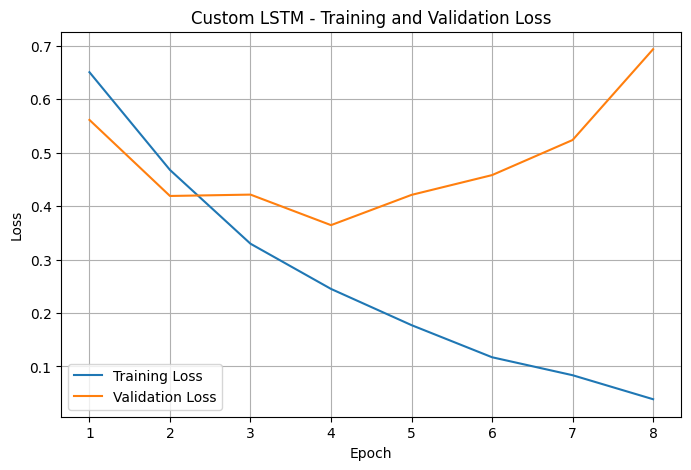

In [22]:
plot_loss(history)

In [23]:
def plot_validation_metrics(history):
    epochs = range(1, len(history["val_accuracy"]) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["val_accuracy"],
        label="Accuracy"
    )

    plt.plot(
        epochs,
        history["val_precision"],
        label="Precision"
    )

    plt.plot(
        epochs,
        history["val_recall"],
        label="Recall"
    )

    plt.plot(
        epochs,
        history["val_f1"],
        label="F1 Score"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Custom LSTM - Validation Metrics")
    plt.legend()
    plt.grid(True)
    plt.show()

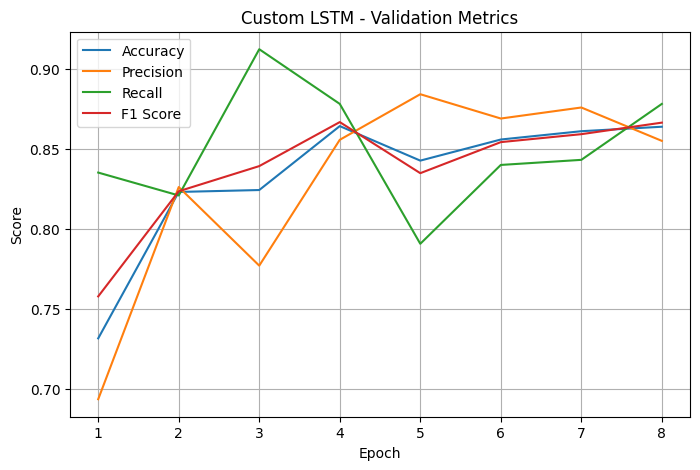

In [24]:
plot_validation_metrics(history)

In [25]:
def plot_learning_rate(history):
    epochs = range(1, len(history["learning_rate"]) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["learning_rate"],
        marker="o"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title("Custom LSTM - Learning Rate Schedule")
    plt.grid(True)
    plt.show()

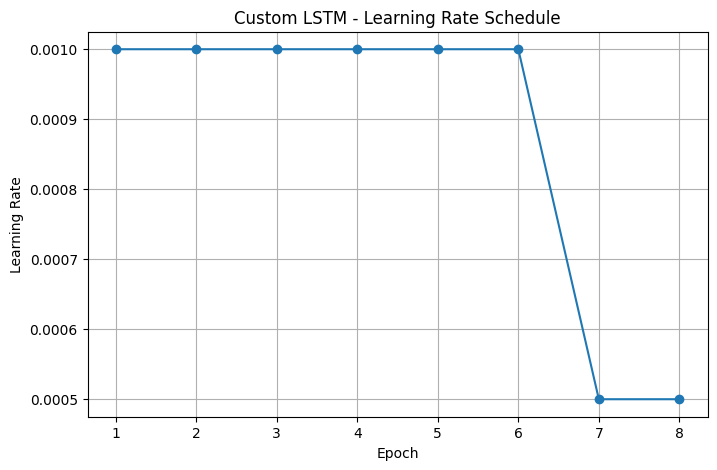

In [26]:
plot_learning_rate(history)

**Final Model Evaluation**

After training is complete, the best-performing Custom LSTM model is evaluated on the held-out IMDb test set.

The test set was not used during training, hyperparameter selection, learning-rate scheduling, or early stopping.

The following classification metrics are calculated:

- **Accuracy** — proportion of correctly classified reviews.
- **Precision** — proportion of predicted positive reviews that are actually positive.
- **Recall** — proportion of actual positive reviews correctly identified.
- **F1-score** — harmonic mean of precision and recall.

The predicted labels are generated from the class with the highest output logit.

In [27]:
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


def evaluate_model(model, dataloader):

    device = next(model.parameters()).device

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for batch in dataloader:

            inputs = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            outputs = model(inputs)

            predictions = outputs.argmax(dim=1)

            all_preds.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            all_labels,
            all_preds,
            average="binary",
            zero_division=0
        )
    )

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    return metrics

In [28]:
# Evaluate the model
test_metrics = evaluate_model(
    trained_model,
    test_loader
)

Accuracy:  0.8428
Precision: 0.8375
Recall:    0.8505
F1 Score:  0.8440


**Single Review Prediction**

A prediction function is provided to classify a new movie review using the trained Custom LSTM model.

The input review follows the same preprocessing pipeline used during training:

1. Convert the text to lowercase.
2. Apply the same text cleaning procedure.
3. Tokenize the review.
4. Convert tokens into vocabulary IDs.
5. Replace unknown words with `<unk>`.
6. Truncate sequences longer than 200 tokens.
7. Pad shorter sequences to 200 tokens.

The processed review is then passed through the trained model. Softmax is applied to the model logits to obtain the predicted class probabilities.

The class with the highest probability is returned as either **Positive** or **Negative**, along with its predicted class probability.

In [29]:
def predict(text, model, vocab, max_len=200):

    device = next(model.parameters()).device

    # Use the same preprocessing as training
    tokens = clean_text(text).split()

    # Convert tokens to vocabulary IDs
    ids = [
        vocab.get(token, vocab["<unk>"])
        for token in tokens
    ]

    # Truncate
    ids = ids[:max_len]

    # Pad
    padding_length = max_len - len(ids)

    ids += [
        vocab["<pad>"]
    ] * padding_length

    # Add batch dimension
    tensor = torch.tensor(
        ids,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        output = model(tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

    prediction = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = probabilities[
        0, prediction
    ].item()

    label = (
        "Positive"
        if prediction == 1
        else "Negative"
    )

    return label, confidence

**Example Prediction**

The trained Custom LSTM is tested on a new movie review that is not part of the IMDb dataset.

The model predicts the sentiment class and returns the corresponding softmax probability for the predicted class.

This demonstrates how the trained model can be used for inference on previously unseen text.

In [30]:
text = "An emotionally resonant experience with nuanced performances that stay with you long after the credits roll. The director has crafted a beautiful story that is both intimate and deeply moving. Highly recommended." 
predict(text, model, vocab)

('Positive', 0.998051643371582)

In [31]:
text = "I grew up...watching and loving [the original]. What they did to this is a disaster...completely ruined the legacy"
predict(text, model, vocab)

('Negative', 0.5684219598770142)